In [40]:
#Import Pandas

import pandas as pd

In [41]:
#Read in the .csv file with pandas read_csv

data = pd.read_csv('credit_card.csv')

In [42]:
#Display the first 5 rows of data with .head() method

data.head(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:18:07,343464013864032,fraud_Kunde-Sanford,misc_net,2.55,Jodi,Foster,F,551 Zachary Freeway,Bailey,...,35.8072,-78.0892,6629,Call centre manager,1962-08-13,abe0676c18f34fa305b113fa762e29b5,1325377087,36.749870,-78.677870,0
2,2019-01-01 00:37:18,4265776278887457,fraud_Pacocha-O'Reilly,grocery_pos,103.00,Christine,Best,F,68248 Deanna Land,Enola,...,35.2087,-92.2123,969,"Physicist, medical",1954-01-05,289789e617eece42a9cafe36680b1b69,1325378238,35.034285,-92.343010,0
3,2019-01-01 00:56:59,571465035400,"fraud_Reichert, Huels and Hoppe",shopping_net,113.40,Louis,Fisher,M,45654 Hess Rest,Fort Washakie,...,43.0048,-108.8964,1645,Freight forwarder,1976-02-26,9d660a18154a3ba5fe869f373c6f819c,1325379419,42.868965,-108.503350,0
4,2019-01-01 01:16:52,6593250708747804,fraud_Brekke and Sons,gas_transport,55.18,Melissa,Meza,F,244 Abbott Parkway,Loxahatchee,...,26.7383,-80.2760,26551,Paramedic,1977-01-04,3c6158c556727d527f8b51cc03b30236,1325380612,27.346033,-80.475563,0


In [43]:
#To quickly create the statistical summaries:

data.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,5.907300e+04,59073.000000,59073.000000,59073.000000,59073.000000,5.907300e+04,5.907300e+04,59073.000000,59073.000000,59073.000000
mean,4.155063e+17,125.809682,48936.650805,38.535668,-90.300925,8.999355e+04,1.349139e+09,38.530650,-90.301737,0.127063
std,1.305091e+18,245.649462,26897.427002,5.082398,13.872055,3.056844e+05,1.296902e+07,5.118062,13.884615,0.333046
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.038876,-166.620488,0.000000
25%,1.800462e+14,11.510000,26292.000000,34.703100,-96.798000,7.410000e+02,1.338510e+09,34.795189,-96.904179,0.000000
50%,3.523898e+15,52.520000,48088.000000,39.319900,-87.456900,2.457000e+03,1.349187e+09,39.333993,-87.378850,0.000000
75%,4.642255e+15,101.050000,72042.000000,41.846700,-80.175200,2.032800e+04,1.359542e+09,41.918596,-80.285566,0.000000
max,4.992346e+18,14238.110000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371816e+09,67.510267,-66.961923,1.000000


In [44]:
#To quickly check all columns for null values, there are a few quick options, including .isnull(), but recall that .info() will report all this information for all columns:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 59073 entries, 0 to 59072
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  59073 non-null  str    
 1   cc_num                 59073 non-null  int64  
 2   merchant               59073 non-null  str    
 3   category               59073 non-null  str    
 4   amt                    59073 non-null  float64
 5   first                  59073 non-null  str    
 6   last                   59073 non-null  str    
 7   gender                 59073 non-null  str    
 8   street                 59073 non-null  str    
 9   city                   59073 non-null  str    
 10  state                  59073 non-null  str    
 11  zip                    59073 non-null  int64  
 12  lat                    59073 non-null  float64
 13  long                   59073 non-null  float64
 14  city_pop               59073 non-null  int64  
 15  job          

In [45]:
#use groupby() to separate based on the is_fraud column categories and then calculate the mean and median values:

print("Median Spend per Fraud Category:")
print(data.groupby("is_fraud")["amt"].median())
print('\n')
print("Mean Spend per Fraud Category:")
print(data.groupby("is_fraud")["amt"].mean())

Median Spend per Fraud Category:
is_fraud
0     47.240
1    396.505
Name: amt, dtype: float64


Mean Spend per Fraud Category:
is_fraud
0     66.784314
1    531.320092
Name: amt, dtype: float64


In [46]:
#use groupby to do both operations with a single line:

data[(data["cc_num"] == 344709867813900)].groupby('is_fraud').sum()["amt"]

is_fraud
0    11667.49
1     6450.28
Name: amt, dtype: float64

In [47]:
#Drop the columns

data = data.drop(["unix_time", "trans_num"], axis=1)

In [48]:
#Remove the date portion of the timestamp

data["trans_date_trans_time"] = data["trans_date_trans_time"].apply(lambda x: x.split(" ")[1])

In [49]:
#Create a function to bin timestamps into categories

def quantitize(string):
    time_hour = int(string[:2])
    if time_hour < 6:
        return 0
    elif 6 <= time_hour < 12:
        return 1
    elif 12 <= time_hour <18:
        return 2
    else:
        return 3

In [50]:
#Apply the function

data["trans_date_trans_time"] = data["trans_date_trans_time"].apply(quantitize)

In [51]:
#Confirm with a value count:

data["trans_date_trans_time"].value_counts()


trans_date_trans_time
3    19819
2    16133
0    12714
1    10407
Name: count, dtype: int64

In [52]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
plt.figure(figsize=(6,4),dpi=150)

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

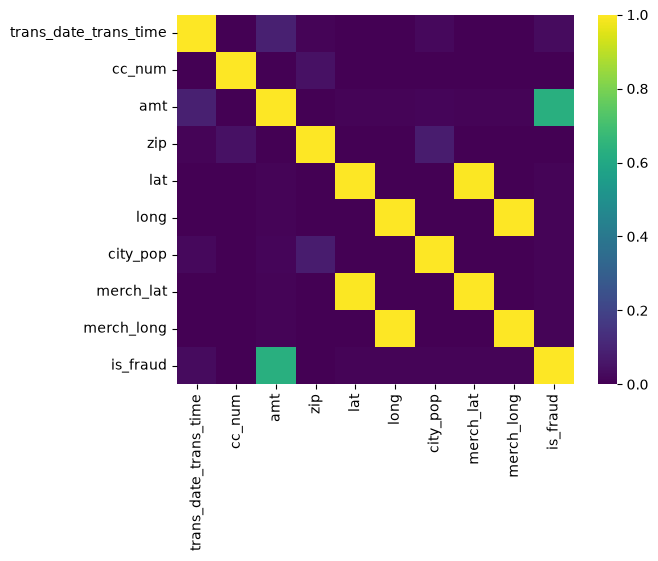

In [54]:
# Select only numeric columns for the heatmap
sns.heatmap(data.select_dtypes(include='number').corr(), 
            vmin=0, vmax=1, cmap="viridis")
plt.show()

In [55]:
#Perform Imports of Scikit-Learn

from sklearn.preprocessing import LabelEncoder

In [56]:
#Create the encoder

encoder = LabelEncoder()

In [57]:
#Get the categorical features with Pandas

categorical_features = data.select_dtypes(include=['string', 'object']).columns
categorical_features

Index(['merchant', 'category', 'first', 'last', 'gender', 'street', 'city',
       'state', 'job', 'dob'],
      dtype='str')

In [58]:
 #Apply fit_transform to create the encoded category data columns

data_encoded = data.copy()
data_encoded[categorical_features] = data_encoded[categorical_features].apply(encoder.fit_transform)
 
# Display dataframe
data_encoded

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud
0,0,2703186189652095,514,8,4.97,162,18,0,568,526,27,28654,36.0788,-81.1781,3495,370,779,36.011293,-82.048315,0
1,0,343464013864032,351,8,2.55,171,138,0,552,45,27,27807,35.8072,-78.0892,6629,59,317,36.749870,-78.677870,0
2,0,4265776278887457,468,4,103.00,73,30,0,681,250,2,72047,35.2087,-92.2123,969,337,182,35.034285,-92.343010,0
3,0,571465035400,502,11,113.40,222,127,1,464,272,50,82514,43.0048,-108.8964,1645,202,572,42.868965,-108.503350,0
4,0,6593250708747804,77,2,55.18,239,285,0,236,463,9,33470,26.7383,-80.2760,26551,327,589,27.346033,-80.475563,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59068,0,3524574586339330,295,11,977.01,27,54,0,928,829,9,32960,27.6330,-80.4031,105638,271,741,26.888686,-80.834389,1
59069,0,3524574586339330,571,11,1210.91,27,54,0,928,829,9,32960,27.6330,-80.4031,105638,271,741,28.216707,-79.855648,1
59070,0,4005676619255478,622,2,10.24,348,339,1,465,209,18,70726,30.4590,-90.9027,71335,222,880,29.700456,-91.361632,1
59071,0,3560725013359375,107,2,21.69,51,404,0,640,592,43,79759,31.8599,-102.7413,23,115,446,32.675272,-103.484949,1


In [64]:
#Import tools from scikit-learn
from sklearn.model_selection import train_test_split

#Separate Features and Label

X = data_encoded.drop("is_fraud", axis=1)
y = data_encoded["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (53165, 19)
Test set size: (5908, 19)


In [65]:
#Import Random Forest class

from sklearn.ensemble import RandomForestClassifier

#Create the instance of the model (you can also edit hyperparameters further)

classifier = RandomForestClassifier(class_weight='balanced')

#Fit the classifier to the training data set

classifier.fit(X_train, y_train)

,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fa

In [66]:
#Import the metrics methods

from sklearn.metrics import accuracy_score, confusion_matrix

#Create the predictions

preds = classifier.predict(X_test)


In [69]:
#Calculate the accuracy

accuracy_score(preds, y_test)

0.9817197020988491

In [70]:
#Create the confusion matrix

confusion_matrix(y_test, preds)

array([[5083,   48],
       [  60,  717]])